# c50py vs gradient boosting: how much does a readable model cost?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/daviddiazsolis/c50py/blob/main/examples/notebooks/03_c50py_vs_gradient_boosting.ipynb)

Gradient boosting (here scikit-learn's `HistGradientBoostingClassifier`, HGB) and random forests
are the usual benchmark for tabular data: hundreds of trees whose votes are added up. They are
often the most accurate option, and nobody can read them. A single C5.0 tree or a C5.0 ruleset is
the opposite trade.

The question of this notebook is a practical one: **on a given problem, how many points of
accuracy does the readable model give up?** Sometimes the answer is "several", and the ensemble is
worth its opacity. Often it is "one or none", and then a model that a manager, an auditor or a
regulator can read is the better choice.

We compare five models with 5-fold cross-validation on four datasets:

* `C5Classifier()`: one C5.0 tree, defaults.
* `C5RulesClassifier()`: a C5.0 ruleset (notebook 04 explains what it is).
* `C5Classifier(trials=10)`: C5.0's own boosting, ten trees that vote.
* `HistGradientBoostingClassifier`: gradient boosting with native categorical support, defaults.
* `RandomForestClassifier`: 300 trees on one-hot encoded data.

In [1]:
# Colab / a fresh environment: install c50py (0.5 or later)
import importlib, subprocess, sys
try:
    import c50py
    assert tuple(int(v) for v in c50py.__version__.split(".")[:2]) >= (0, 5)
except (ImportError, AssertionError):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "--upgrade", "c50py>=0.5.0"], check=True)
    import c50py
    importlib.reload(c50py)
print("c50py", c50py.__version__)

c50py 0.5.0


In [2]:
import time, warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import make_column_transformer
from sklearn.datasets import fetch_openml
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder
from c50py import C5Classifier, C5RulesClassifier

def load(data_id):
    d = fetch_openml(data_id=data_id, as_frame=True, parser="pandas")
    X = d.data.copy()
    for c in X.columns:
        if str(X[c].dtype) in ("object", "str", "string", "bool"):
            X[c] = X[c].astype("category")
    return d.details["name"], X, d.target.astype(str).to_numpy()

def models(X):
    cats = [c for c in X.columns if str(X[c].dtype) == "category"]
    onehot = make_column_transformer((OneHotEncoder(handle_unknown="ignore"), cats), remainder="passthrough")
    return {
        "C5.0 tree": C5Classifier(),
        "C5.0 ruleset": C5RulesClassifier(),
        "C5.0 boosting (10 trials)": C5Classifier(trials=10),
        "HistGradientBoosting": HistGradientBoostingClassifier(categorical_features="from_dtype", random_state=0),
        "Random forest + one-hot": make_pipeline(onehot, RandomForestClassifier(300, n_jobs=-1, random_state=0)),
    }

## 1. The data

* `credit-g`: 1,000 loan applicants, 13 categorical and 7 numeric columns. Noisy: even the best
  models get about a quarter of the cases wrong.
* `churn`: 5,000 telecom customers, mostly numeric columns (minutes, charges, calls to customer
  service).
* `car`: 1,728 car evaluations, all 6 columns categorical, 4 classes. The class was produced by a
  set of logical rules, so there is a "true" readable model.
* `tic-tac-toe`: 958 end positions of the game, 9 categorical columns (the squares), won or not.
  Also logical, but the rule ("three in a line") is hard to express with one test at a time.

## 2. Cross-validation

For each dataset and model: accuracy and the area under the ROC curve (AUC, one class against the
rest when there are more than two classes), averaged over five folds, and the time to fit one
model. Accuracy measures the decisions; AUC measures how well the model ranks cases by risk, which
is what matters when a campaign or a review can only reach the top of the list. This cell takes a
few minutes.

In [3]:
cv = StratifiedKFold(5, shuffle=True, random_state=0)
rows = []
for data_id in [31, 40701, 40975, 50]:
    name, X, y = load(data_id)
    scoring = {"accuracy": "accuracy", "auc": "roc_auc" if len(np.unique(y)) == 2 else "roc_auc_ovr"}
    for label, model in models(X).items():
        r = cross_validate(model, X, y, cv=cv, scoring=scoring)
        rows.append(dict(dataset=name, model=label, accuracy=r["test_accuracy"].mean(),
                         auc=r["test_auc"].mean(), fit_seconds=r["fit_time"].mean()))
results = pd.DataFrame(rows)
results.pivot(index="model", columns="dataset", values="accuracy").round(3)

dataset,car,churn,credit-g,tic-tac-toe
model,,,,
C5.0 boosting (10 trials),0.981,0.955,0.730,0.981
C5.0 ruleset,0.981,0.948,0.729,0.976
C5.0 tree,0.973,0.944,0.723,0.951
HistGradientBoosting,0.995,0.960,0.766,0.993
Random forest + one-hot,0.962,0.951,0.758,0.991


In [4]:
results.pivot(index="model", columns="dataset", values="auc").round(3)

dataset,car,churn,credit-g,tic-tac-toe
model,,,,
C5.0 boosting (10 trials),0.999,0.919,0.748,0.998
C5.0 ruleset,0.994,0.900,0.720,0.985
C5.0 tree,0.978,0.858,0.630,0.973
HistGradientBoosting,0.999,0.921,0.784,0.999
Random forest + one-hot,0.997,0.914,0.799,0.999


In [5]:
results.pivot(index="model", columns="dataset", values="fit_seconds").round(2)

dataset,car,churn,credit-g,tic-tac-toe
model,,,,
C5.0 boosting (10 trials),0.73,12.53,4.71,0.93
C5.0 ruleset,0.16,1.22,0.64,0.13
C5.0 tree,0.10,0.84,0.48,0.08
HistGradientBoosting,0.59,0.28,0.18,0.14
Random forest + one-hot,0.61,1.25,0.52,0.49


## 3. The gap, in one picture

For each dataset, the accuracy of each model minus the accuracy of HGB. A bar at zero means the
model is as accurate as gradient boosting; a bar of minus 0.05 means it gets five more cases in a
hundred wrong.

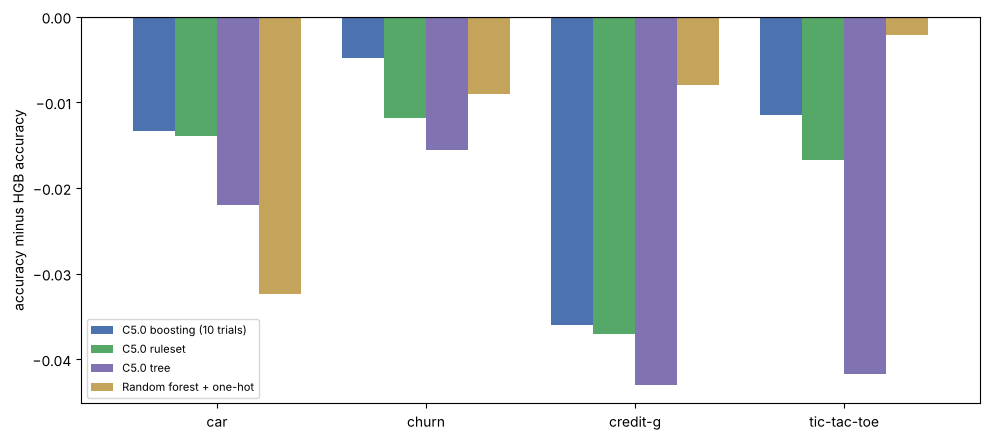

In [6]:
acc = results.pivot(index="dataset", columns="model", values="accuracy")
gap = acc.sub(acc["HistGradientBoosting"], axis=0).drop(columns="HistGradientBoosting")
ax = gap.plot.bar(figsize=(10, 4.5), width=0.8, color=["#4c72b0", "#55a868", "#8172b2", "#c4a35a"])
ax.axhline(0, color="black", lw=0.8)
ax.set_ylabel("accuracy minus HGB accuracy"); ax.set_xlabel("")
ax.legend(loc="lower left", fontsize=8); plt.xticks(rotation=0); plt.tight_layout(); plt.show()

How to read the results:

* **Gradient boosting is the most accurate model on all four datasets.** That is the expected
  result and the reason it is the benchmark.
* **The ruleset is the best of the readable models**, and it is between one and two points behind
  HGB on `churn`, `tic-tac-toe` and `car`: a model of a few dozen rules, or fewer, that can be
  printed and discussed, for one or two more errors in a hundred cases.
* **`credit-g` is the hard case for a single model.** About 70% of the applicants are good payers,
  so always answering "good" already gives 0.70, and the single tree barely beats that. The data
  are noisy and the signal is spread over many weak variables, which is exactly where averaging
  hundreds of trees pays off (the random forest is as good as HGB here). A ruleset is still useful
  to describe the main risk profiles, but it should not be sold as the most accurate scoring model.
* **C5.0's own boosting closes most of the gap** on `churn`, `car` and `tic-tac-toe` (within one
  and a half points of HGB) while keeping C5.0's handling of categories and missing values.
* **AUC separates the models more than accuracy.** A single tree gives the same probability to all
  cases in a leaf, so it ranks cases coarsely (AUC 0.63 against 0.78 on `credit-g`). If what
  matters is the order of a list (who to call first), use an ensemble or C5.0 boosting for the
  ranking, and the ruleset to explain it.

The practical recipe that follows: fit the readable model and the ensemble, and look at the gap.
If it is small, use the readable model, or use it to explain and check the ensemble. If it is
large, the ensemble is finding structure the tree cannot express in a few tests, which is worth
knowing too.

## 4. What "readable" buys, in numbers

The size of each model on `credit-g`: what someone would have to read to understand all the
decisions it can make.

In [7]:
name, X, y = load(31)
tree = C5Classifier().fit(X, y)
ruleset = C5RulesClassifier().fit(X, y)
boost = C5Classifier(trials=10).fit(X, y)
hgb = HistGradientBoostingClassifier(categorical_features="from_dtype", random_state=0).fit(X, y)
def n_leaves(node):
    return 1 if node.is_leaf else sum(n_leaves(ch) for ch in node.children.values())
hgb_leaves = sum(p.get_n_leaf_nodes() for it in hgb._predictors for p in it)
print(f"C5.0 tree:     {len(tree.export_rules())} rules (leaves)")
print(f"C5.0 ruleset:  {len(ruleset.rules_)} rules, "
      f"{np.mean([len(r.conditions) for r in ruleset.rules_]):.1f} conditions per rule on average")
print(f"C5.0 boosting: {len(boost.ensemble_)} trees, {sum(n_leaves(t) for t in boost.ensemble_)} leaves in total")
print(f"HGB:           {hgb.n_iter_} trees, {hgb_leaves} leaves in total")

C5.0 tree:     83 rules (leaves)
C5.0 ruleset:  39 rules, 4.9 conditions per rule on average
C5.0 boosting: 10 trees, 1055 leaves in total
HGB:           100 trees, 3100 leaves in total


A ruleset of a few dozen rules fits on two pages and can be discussed in a meeting; three
thousand leaves cannot. The five most confident rules of the ruleset, with the share of cases each one
gets right (confidence) and how much more frequent its class is among those cases than overall
(lift):

In [8]:
pd.set_option("display.max_colwidth", 160)
ruleset.export_ruleset(as_frame=True).head(5)

,rule_id,conditions,prediction,cases,errors,confidence,lift
0,1,credit_history IN {existing paid} AND duration <= 11 AND installment_commitment > 1.5 AND age > 30.5,good,36.0,0.0,0.974,1.39
1,2,duration <= 22.5 AND savings_status IN {no known savings} AND other_parties IN {none} AND existing_credits <= 1.5 AND own_telephone IN {none} AND personal_s...,good,18.0,0.0,0.950,1.36
2,3,"checking_status IN {0<=X<200, <0} AND credit_history IN {all paid, no credits/all paid} AND housing NOT IN {own} AND other_parties IN {none}",bad,26.0,1.0,0.929,3.10
3,4,"checking_status IN {0<=X<200, <0} AND credit_history IN {existing paid} AND duration <= 22.5 AND other_parties NOT IN {none}",good,26.0,1.0,0.929,1.33
4,5,"checking_status IN {0<=X<200, <0} AND credit_history NOT IN {all paid, no credits/all paid} AND duration > 38 AND other_parties IN {none} AND savings_status...",bad,23.0,1.0,0.920,3.07


## 5. Speed

C5.0 is written in Python and numpy here, not in C. A single tree or a ruleset fits in about a
second on these data, and boosting takes about ten times as long. The times in the table depend on
the machine (HGB uses all the cores, and is the fastest option on large tables). For tables of up
to a few hundred thousand rows c50py is fast enough for interactive work; for millions of rows,
fit it on a sample.